# Feature Importance — Analysis & Visualization

Analyzes the shrinkage-model feature importance results across every round run so far:
permutation importance (individual + grouped GDELT + `heading_idx` mechanism), leave-one-out retraining, the RF cross-check, and every retraining-based feature-removal variant tried (simplified, partial-pair, gravity-edge). Sections for optional files degrade gracefully if that experiment hasn't been run yet or hasn't finished -- this notebook works with whatever subset of results currently exists.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#111111', 'axes.facecolor': '#111111', 'savefig.facecolor': '#111111',
    'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 10,
})
BLUE, ORANGE, POS, NEG, PURPLE, GRAY = '#4c8fbd', '#c47f3e', '#2ca02c', '#d62728', '#9467bd', '#888888'

REQUIRED = 'feature_importance_shrinkage_summary.csv'
OPTIONAL = {
    'raw':          'feature_importance_shrinkage.csv',
    'loo':          'results_leave_one_out.csv',
    'rf':           'rf_vs_permutation_importance.csv',
    'simplified':   'results_simplified_edgegat.csv',      # drop all 4 pair_* + cmdCode
    'partial_pair': 'results_partial_pair_edgegat.csv',    # keep pair_events + pair_score_mean only
    'gravity':      'results_gravity_edge.csv',            # gdpcap_d/pop_d -> gdpcap_gap/pop_gap on edges
    'shrink_orig':  'results_shrinkage_head.csv',          # CANONICAL original values -- run_shrinkage_head.py's own output
    'shrink_orig':  'results_shrinkage_head.csv',          # CANONICAL original values -- run_shrinkage_head.py's own output
}

assert os.path.exists(REQUIRED), f'{REQUIRED} not found -- this is the one file everything else needs.'
summary = pd.read_csv(REQUIRED, index_col=0)

available = {}
for key, path in OPTIONAL.items():
    if os.path.exists(path):
        available[key] = pd.read_csv(path)
        print(f'  [found]   {key:14s} -> {path}  ({len(available[key])} rows)')
    else:
        print(f'  [missing] {key:14s} -> {path}  (that section will be skipped below)')

print(f'\nRequired summary loaded: {len(summary)} features, {int(summary["n_runs"].max())} models max per feature.')

  [found]   raw            -> feature_importance_shrinkage.csv  (344 rows)
  [found]   loo            -> results_leave_one_out.csv  (71 rows)
  [found]   rf             -> rf_vs_permutation_importance.csv  (19 rows)
  [found]   simplified     -> results_simplified_edgegat.csv  (12 rows)
  [found]   partial_pair   -> results_partial_pair_edgegat.csv  (12 rows)
  [found]   gravity        -> results_gravity_edge.csv  (12 rows)
  [found]   shrink_orig    -> results_shrinkage_head.csv  (18107 rows)

Required summary loaded: 19 features, 19 models max per feature.


## 1. Global ranked importance — every feature, aggregated across all models

Error bars show `std_log_r2` across models — a feature with a big mean but a big std relative to it is a much shakier "important" than one with a small std. `refYear` is excluded (constant in the 2023-only eval set, so permutation importance can't measure it — not evidence it's unused).

,n_runs,mean_log_r2,std_log_r2,mean_spearman,frac_negative
feature_clean,,,,,
heading_idx,19,0.3448,0.0166,0.2644,0.0000
gdpcap_o,19,0.2761,0.0495,0.2070,0.0000
pop_o,19,0.2403,0.0726,0.1758,0.0000
gdelt_block,18,0.1360,0.0323,0.0993,0.0000
events_total,18,0.0959,0.0658,0.0488,0.0000
tone_mean,18,0.0820,0.0346,0.0632,0.0000
goldstein_wmean,18,0.0812,0.0579,0.0383,0.0000
active_months,18,0.0559,0.0360,0.0241,0.0000
score_mean,18,0.0516,0.0639,0.0267,0.0000


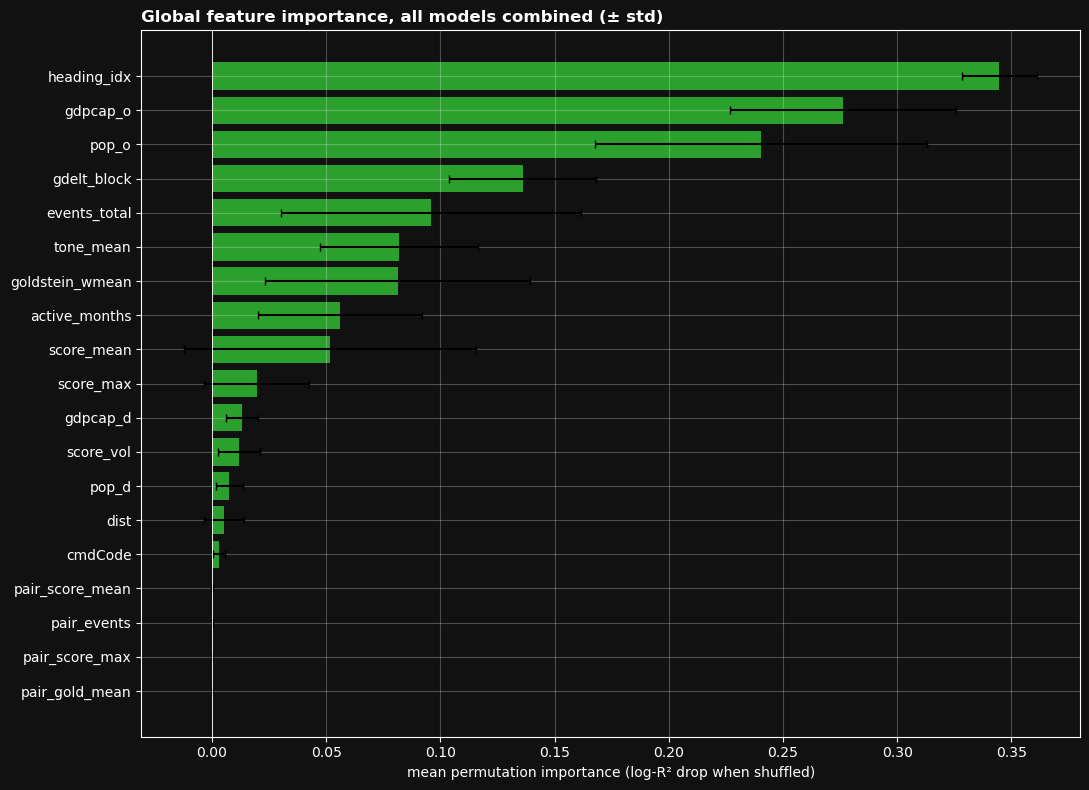

In [2]:
s = summary[summary.index != 'refYear'].sort_values('mean_log_r2', ascending=False)

fig, ax = plt.subplots(figsize=(11, 8))
colors = [POS if v >= 0 else NEG for v in s['mean_log_r2']]
ax.barh(s.index, s['mean_log_r2'], xerr=s['std_log_r2'], color=colors, capsize=3)
ax.axvline(0, color='w', lw=.6)
ax.set_xlabel('mean permutation importance (log-R² drop when shuffled)')
ax.set_title('Global feature importance, all models combined (± std)', loc='left', fontweight='bold')
ax.invert_yaxis()
fig.tight_layout()

s[['n_runs','mean_log_r2','std_log_r2','mean_spearman','frac_negative']]

## 2. KEEP / BORDERLINE / REMOVE verdict (from permutation importance alone)

A feature earns REMOVE only if its mean is near-zero/negative AND it's not just noisy. **Read this alongside Section 7 below** -- permutation importance and full retraining disagreed sharply in this project's actual results, so this verdict alone should not be taken as the final word.

In [3]:
REMOVE_THRESHOLD = 0.01
BORDERLINE_THRESHOLD = 0.02

def verdict(row):
    if row['mean_log_r2'] <= REMOVE_THRESHOLD and row['frac_negative'] >= 0.3:
        return 'REMOVE'
    if row['mean_log_r2'] <= BORDERLINE_THRESHOLD:
        return 'BORDERLINE'
    return 'KEEP'

s2 = s.copy()
s2['verdict'] = s2.apply(verdict, axis=1)

for v in ['KEEP', 'BORDERLINE', 'REMOVE']:
    feats = s2[s2.verdict == v]
    print(f'\n{v} ({len(feats)} features):')
    for feat, row in feats.iterrows():
        print(f'  {feat:18s} mean={row["mean_log_r2"]:+.4f}  frac_negative={row["frac_negative"]:.2f}')

s2[['mean_log_r2','frac_negative','verdict']]


KEEP (9 features):
  heading_idx        mean=+0.3448  frac_negative=0.00
  gdpcap_o           mean=+0.2761  frac_negative=0.00
  pop_o              mean=+0.2403  frac_negative=0.00
  gdelt_block        mean=+0.1360  frac_negative=0.00
  events_total       mean=+0.0959  frac_negative=0.00
  tone_mean          mean=+0.0820  frac_negative=0.00
  goldstein_wmean    mean=+0.0812  frac_negative=0.00
  active_months      mean=+0.0559  frac_negative=0.00
  score_mean         mean=+0.0516  frac_negative=0.00

BORDERLINE (6 features):
  score_max          mean=+0.0195  frac_negative=0.00
  gdpcap_d           mean=+0.0130  frac_negative=0.00
  score_vol          mean=+0.0118  frac_negative=0.00
  pop_d              mean=+0.0075  frac_negative=0.05
  dist               mean=+0.0053  frac_negative=0.11
  cmdCode            mean=+0.0030  frac_negative=0.00

REMOVE (4 features):
  pair_score_mean    mean=+0.0001  frac_negative=0.67
  pair_events        mean=+0.0001  frac_negative=0.33
  pair_score_m

,mean_log_r2,frac_negative,verdict
feature_clean,,,
heading_idx,0.3448,0.0000,KEEP
gdpcap_o,0.2761,0.0000,KEEP
pop_o,0.2403,0.0000,KEEP
gdelt_block,0.1360,0.0000,KEEP
events_total,0.0959,0.0000,KEEP
tone_mean,0.0820,0.0000,KEEP
goldstein_wmean,0.0812,0.0000,KEEP
active_months,0.0559,0.0000,KEEP
score_mean,0.0516,0.0000,KEEP


## 3. Grouped GDELT test — does testing GDELT columns individually understate the block?

Compares `gdelt_block` (all 7 GDELT columns shuffled together, preserving within-row correlation) against the best individual GDELT column.

gdelt_block (all 7 together): 0.1360
best individual column (events_total): 0.0959
block scores +41.8% higher than the best individual GDELT column


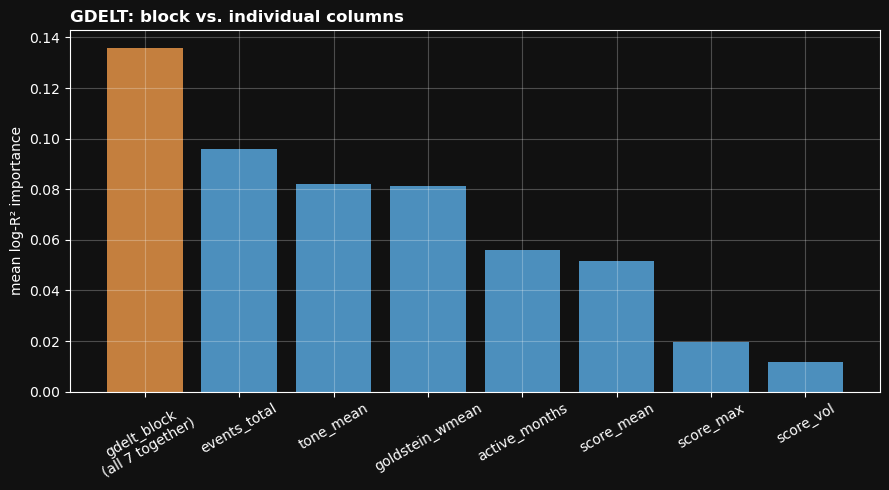

In [4]:
GDELT_COLS = ['events_total','score_mean','score_max','score_vol','goldstein_wmean','tone_mean','active_months']
if 'gdelt_block' in summary.index:
    block_val = summary.loc['gdelt_block', 'mean_log_r2']
    individual = summary.loc[summary.index.isin(GDELT_COLS), 'mean_log_r2']
    best_individual = individual.max()
    best_individual_name = individual.idxmax()
    lift = (block_val - best_individual) / best_individual * 100
    print(f'gdelt_block (all 7 together): {block_val:.4f}')
    print(f'best individual column ({best_individual_name}): {best_individual:.4f}')
    print(f'block scores {lift:+.1f}% higher than the best individual GDELT column')

    fig, ax = plt.subplots(figsize=(9, 5))
    labels = ['gdelt_block\n(all 7 together)'] + list(individual.sort_values(ascending=False).index)
    values = [block_val] + list(individual.sort_values(ascending=False).values)
    colors_b = [ORANGE] + [BLUE]*len(individual)
    ax.bar(labels, values, color=colors_b)
    ax.set_ylabel('mean log-R² importance')
    ax.set_title('GDELT: block vs. individual columns', loc='left', fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    fig.tight_layout()
else:
    print('gdelt_block not in summary -- rerun feature_importance_shrinkage.py with the grouped-GDELT edit first.')

## 4. Per-model consistency (optional — needs the raw per-model file)

A heatmap of feature × model shows whether a feature's importance is stable across every model, or wildly different in one particular config (the signature of a degenerate/collapsed training run).

No model shows a suspiciously high fraction of exactly-zero importances.


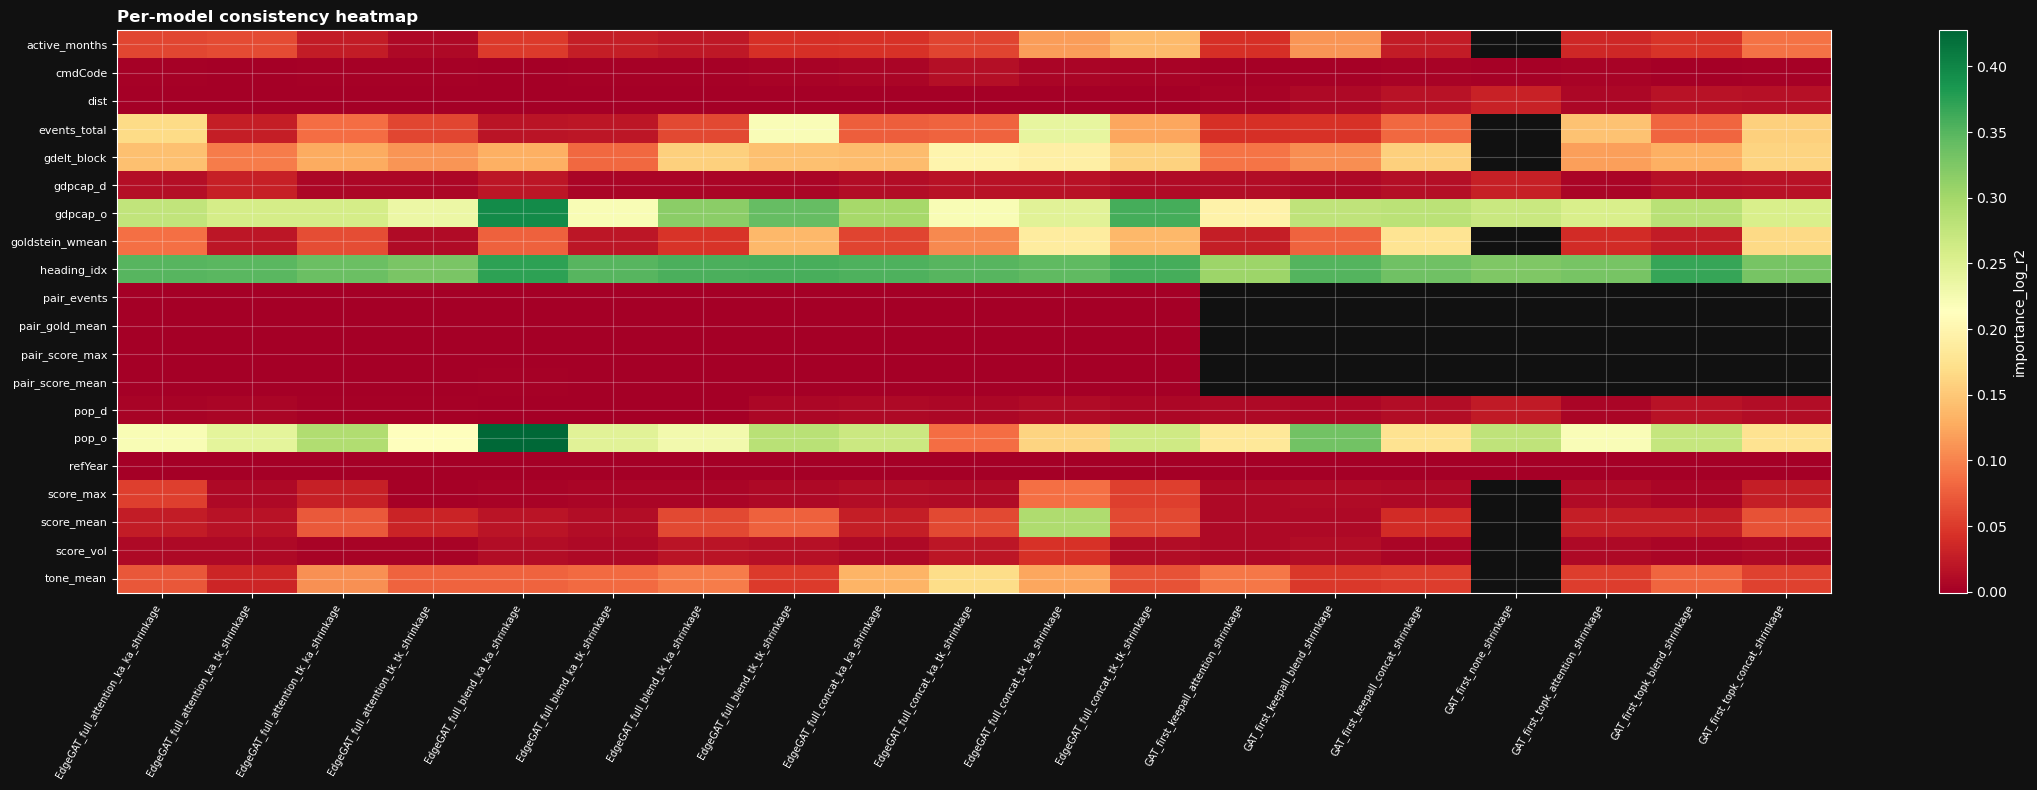

In [5]:
if 'raw' in available:
    raw = available['raw'].copy()
    raw['feature_clean'] = raw['feature'].apply(lambda f: f.split(':', 1)[-1] if ':' in f else f)
    pivot = raw.pivot_table(index='feature_clean', columns='model', values='importance_log_r2', aggfunc='mean')

    fig, ax = plt.subplots(figsize=(max(8, 1.2*pivot.shape[1]), max(6, 0.4*pivot.shape[0])))
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(pivot.shape[1])); ax.set_xticklabels(pivot.columns, rotation=60, ha='right', fontsize=7)
    ax.set_yticks(range(pivot.shape[0])); ax.set_yticklabels(pivot.index, fontsize=8)
    fig.colorbar(im, ax=ax, label='importance_log_r2')
    ax.set_title('Per-model consistency heatmap', loc='left', fontweight='bold')
    fig.tight_layout()

    zero_frac = (raw.groupby('model')['importance_log_r2'].apply(lambda s: (s == 0).mean()))
    suspects = zero_frac[zero_frac > 0.7]
    if len(suspects):
        print('Possible degenerate models (>70% of features show exactly 0 importance):')
        print(suspects.to_string())
    else:
        print('No model shows a suspiciously high fraction of exactly-zero importances.')
else:
    print('feature_importance_shrinkage.csv (raw per-model file) not found -- skipping this section.')

## 5. Leave-one-out retraining (optional — direct, causal confirmation)

Unlike permutation importance, this retrains with the feature genuinely absent. Negative delta = removing it hurt (keep it); positive = removing it helped.

Features that HURT when removed (keep them):
model            EdgeGAT_full_attention_ka_ka  EdgeGAT_full_attention_ka_tk  EdgeGAT_full_blend_tk_ka  EdgeGAT_full_blend_tk_tk  mean_delta
feature_removed                                                                                                                            
pop_o                               -0.369023                     -0.075435                 -0.126752                 -0.119421   -0.172658
score_max                           -0.205179                     -0.225175                 -0.153062                 -0.037447   -0.155216
gdpcap_o                            -0.011551                     -0.203230                 -0.273819                 -0.112250   -0.150212
pop_d                               -0.186887                     -0.210531                 -0.111323                 -0.083695   -0.148109
tone_mean                           -0.235376                     -0.072302                 -0.202421              

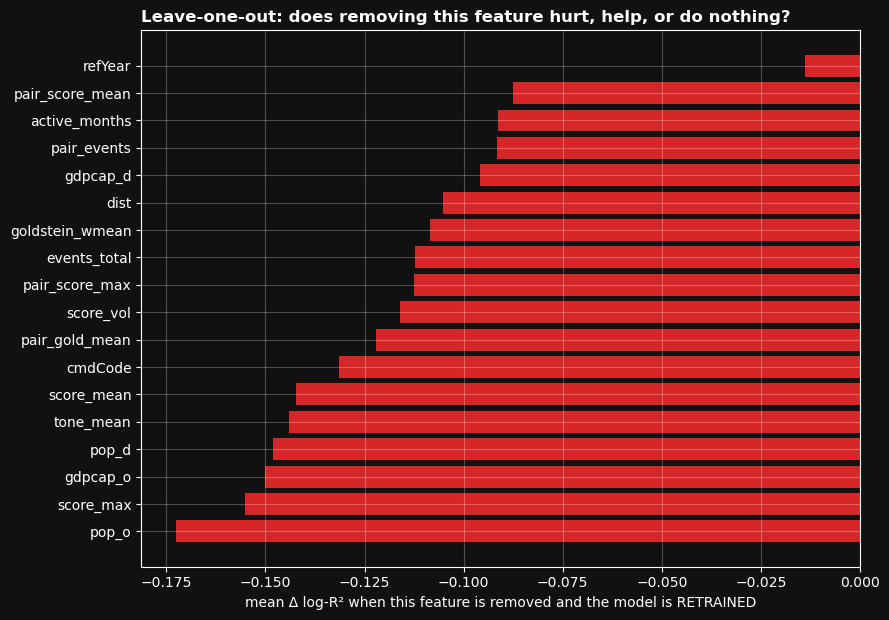

In [6]:
if 'loo' in available:
    loo = available['loo']
    pivot_loo = loo.pivot_table(index='feature_removed', columns='model', values='delta_log_r2')
    pivot_loo['mean_delta'] = pivot_loo.mean(axis=1)
    pivot_loo = pivot_loo.sort_values('mean_delta')

    fig, ax = plt.subplots(figsize=(9, max(5, 0.35*len(pivot_loo))))
    colors_loo = [NEG if v < 0 else POS for v in pivot_loo['mean_delta']]
    ax.barh(pivot_loo.index, pivot_loo['mean_delta'], color=colors_loo)
    ax.axvline(0, color='w', lw=.6)
    ax.set_xlabel('mean Δ log-R² when this feature is removed and the model is RETRAINED')
    ax.set_title('Leave-one-out: does removing this feature hurt, help, or do nothing?', loc='left', fontweight='bold')
    fig.tight_layout()

    print('Features that HURT when removed (keep them):')
    print(pivot_loo[pivot_loo['mean_delta'] < -0.01].to_string())
    print('\nFeatures safe to drop (confirmed by actual retraining):')
    print(pivot_loo[pivot_loo['mean_delta'] >= -0.01].to_string())

    common = pivot_loo.index.intersection(summary.index)
    if len(common) >= 3:
        from scipy.stats import spearmanr
        rho, p = spearmanr(pivot_loo.loc[common, 'mean_delta'], summary.loc[common, 'mean_log_r2'])
        print(f'\nSpearman correlation, leave-one-out delta vs. permutation importance: rho={rho:.3f} (p={p:.4f})')
else:
    print('results_leave_one_out.csv not found -- this experiment may still be running. Skipping this section.')

## 6. RF cross-check (optional — convergent validity across model families)


Spearman rho=-0.126 (p=0.6808), n=13 shared features
         Unnamed: 0  rf_mean   rf_std  rf_n_models  mean_log_r2
0           cmdCode  0.40588  0.00386          3.0       0.0038
1             pop_o  0.18771  0.01307          3.0       0.2265
2          gdpcap_o  0.16109  0.01073          3.0       0.2646
3          gdpcap_d  0.06357  0.00394          3.0       0.0121
4             pop_d  0.06320  0.00417          3.0       0.0073
5              dist  0.05930  0.00206          3.0       0.0046
6         tone_mean  0.01910  0.00385          2.0       0.0815
7   goldstein_wmean  0.01417  0.00094          2.0       0.0593
8        score_mean  0.01090  0.00155          2.0       0.0560
10        score_vol  0.01024  0.00148          2.0       0.0163
11        score_max  0.00972  0.00006          2.0       0.0196
12     events_total  0.00823  0.00719          2.0       0.0954
13    active_months  0.00102  0.00001          2.0       0.0505


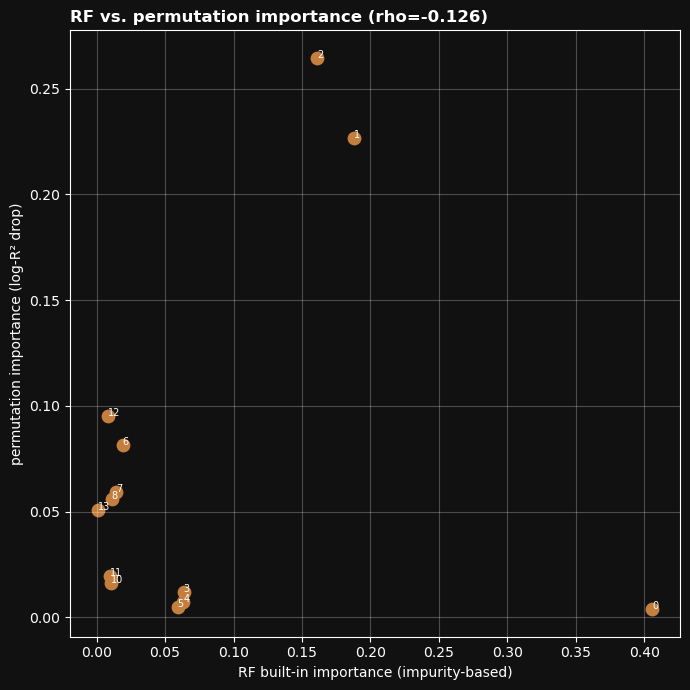

In [7]:
if 'rf' in available:
    rf = available['rf'].set_index('feature_clean') if 'feature_clean' in available['rf'].columns else available['rf']
    both = rf.dropna(subset=['rf_mean', 'mean_log_r2']) if 'rf_mean' in rf.columns and 'mean_log_r2' in rf.columns else rf

    if len(both) >= 3:
        from scipy.stats import spearmanr
        rho, p = spearmanr(both['rf_mean'], both['mean_log_r2'])
        fig, ax = plt.subplots(figsize=(7,7))
        ax.scatter(both['rf_mean'], both['mean_log_r2'], s=80, color=ORANGE)
        for feat in both.index:
            ax.annotate(feat, (both.loc[feat,'rf_mean'], both.loc[feat,'mean_log_r2']), fontsize=7, color='white')
        ax.set_xlabel('RF built-in importance (impurity-based)')
        ax.set_ylabel('permutation importance (log-R² drop)')
        ax.set_title(f'RF vs. permutation importance (rho={rho:.3f})', loc='left', fontweight='bold')
        fig.tight_layout()
        print(f'Spearman rho={rho:.3f} (p={p:.4f}), n={len(both)} shared features')
    print(both.to_string())
else:
    print('rf_vs_permutation_importance.csv not found -- run train_rf_pooled.py + rf_feature_crosscheck.py first. Skipping.')

## 7. Retraining-based feature removal — every variant tried, vs. the CANONICAL original

"Original" here comes from `results_shrinkage_head.csv` (`scope=='overall'`) -- the actual output of `run_shrinkage_head.py` itself, parsed the same way `compare_all_experiments_v2.ipynb` does. This is deliberately **not** each retrain script's own `original_log_r2` column -- those depend on a hand-maintained dict that has been wrong more than once this project. Pulling from the canonical source here means this comparison can't silently go stale or mismatched again.

- **Simplified** — drop all 4 `pair_*` columns and `cmdCode` entirely
- **Partial-pair** — keep only `pair_events` + `pair_score_mean`, drop `pair_score_max` + `pair_gold_mean`
- **Gravity-edge** — replace `gdpcap_d`/`pop_d` node features with `gdpcap_gap`/`pop_gap` on the edges instead


Loaded 12 canonical original values from results_shrinkage_head.csv

=== Summary per variant ===
Simplified                                     2/12 held steady or improved (of 12 with a valid original), 0 genuinely improved, mean delta=-0.1646
Partial-pair                                   1/12 held steady or improved (of 12 with a valid original), 0 genuinely improved, mean delta=-0.1414
Gravity-edge                                   0/12 held steady or improved (of 12 with a valid original), 0 genuinely improved, mean delta=-0.2030


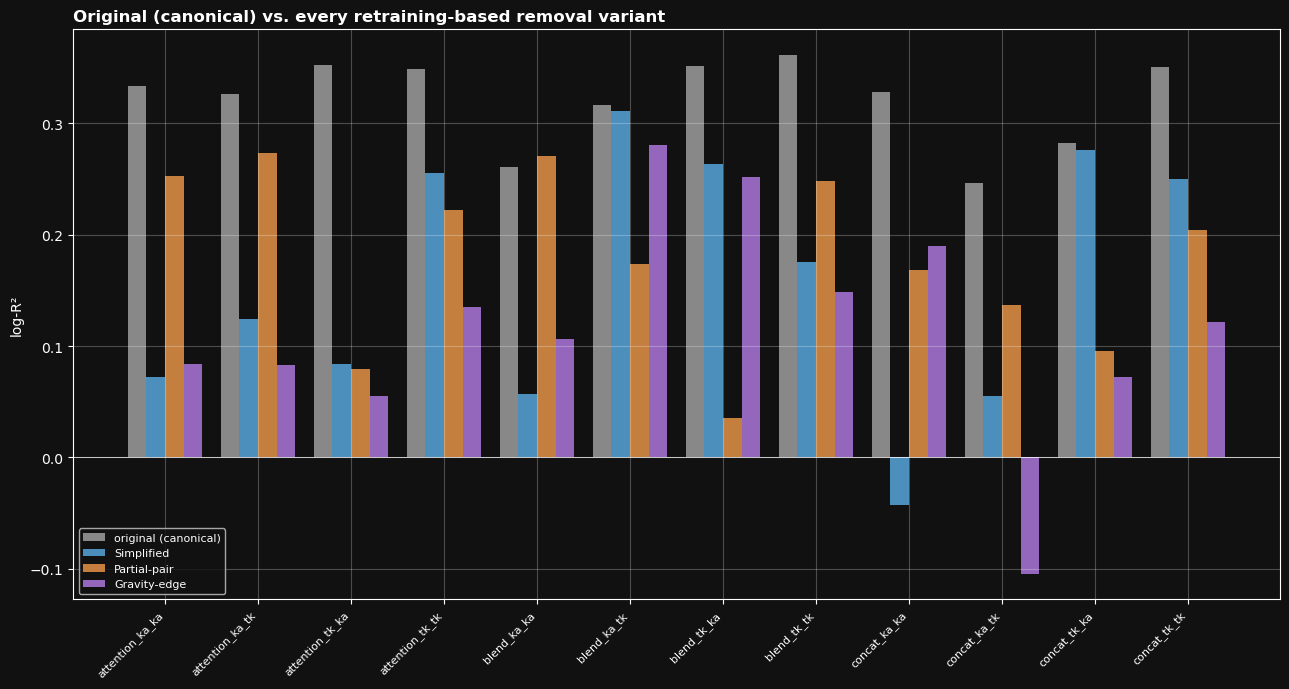

In [8]:
def parse_shrinkage_name(name):
    n = name.replace('_shrinkage', '')
    if n == 'GAT_first_none':
        return ('GAT', 'none', 'none')
    if n.startswith('GAT_first_'):
        rest = n[len('GAT_first_'):]
        scoring, fusion = rest.rsplit('_', 1)
        return ('GAT', fusion, scoring)
    if n.startswith('EdgeGAT_full_'):
        rest = n[len('EdgeGAT_full_'):]
        fusion, combo = rest.split('_', 1)
        return ('EdgeGAT_full', fusion, combo)
    raise ValueError(name)

original_lookup = {}
if 'shrink_orig' in available:
    shrink_df = available['shrink_orig']
    shrink_overall = shrink_df[shrink_df.scope == 'overall'].copy()
    for _, row in shrink_overall.iterrows():
        try:
            kind, fusion, combo = parse_shrinkage_name(row['model'])
        except ValueError:
            continue
        if kind == 'EdgeGAT_full':
            original_lookup[(combo, fusion)] = row['log_r2']
    print(f'Loaded {len(original_lookup)} canonical original values from results_shrinkage_head.csv')
else:
    print('[warn] results_shrinkage_head.csv not found -- original bars/deltas below will be blank. '
          'Run run_shrinkage_head.py, or copy that CSV in, to unlock the original baseline.')

RETRAIN_VARIANTS = [
    ('simplified',   'Simplified\n(drop pair_*, cmdCode)',              'simplified_log_r2'),
    ('partial_pair', 'Partial-pair\n(keep pair_events+score_mean)',     'simplified_log_r2'),
    ('gravity',      'Gravity-edge\n(gdpcap_gap/pop_gap)',              'gravity_log_r2'),
]

variant_rows = []
for key, label, log_r2_col in RETRAIN_VARIANTS:
    if key not in available:
        print(f'[skip] {label.splitlines()[0]} -- {OPTIONAL[key]} not found yet')
        continue
    df = available[key].copy()
    df['original_log_r2'] = df.apply(lambda r: original_lookup.get((r['combo'], r['fusion'])), axis=1)
    df['delta_vs_original'] = df[log_r2_col] - df['original_log_r2']
    variant_rows.append(pd.DataFrame({
        'name': df['name'], 'fusion': df['fusion'], 'combo': df['combo'],
        'log_r2': df[log_r2_col], 'delta_vs_original': df['delta_vs_original'], 'original_log_r2': df['original_log_r2'],
        'variant': label,
    }))

if variant_rows:
    all_variants = pd.concat(variant_rows, ignore_index=True)

    fig, ax = plt.subplots(figsize=(13, 7))
    configs = sorted(all_variants['name'].unique())
    x = np.arange(len(configs))
    variant_labels = [v[1] for v in RETRAIN_VARIANTS if v[0] in available]
    n_v = len(variant_labels)
    w = 0.8 / (n_v + 1)
    colors_v = [BLUE, ORANGE, PURPLE]

    orig_vals = [all_variants[all_variants.name==c]['original_log_r2'].iloc[0] for c in configs]
    ax.bar(x - w*n_v/2, orig_vals, w, label='original (canonical)', color=GRAY)
    for i, (key, label, _) in enumerate([v for v in RETRAIN_VARIANTS if v[0] in available]):
        vals = [all_variants[(all_variants.name==c) & (all_variants.variant==label)]['log_r2']
                .pipe(lambda s: s.iloc[0] if len(s) else np.nan) for c in configs]
        ax.bar(x - w*n_v/2 + w*(i+1), vals, w, label=label.splitlines()[0], color=colors_v[i % len(colors_v)])

    ax.set_xticks(x); ax.set_xticklabels(configs, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('log-R²'); ax.legend(fontsize=8)
    ax.set_title('Original (canonical) vs. every retraining-based removal variant', loc='left', fontweight='bold')
    ax.axhline(0, color='w', lw=.5)
    fig.tight_layout()

    print('\n=== Summary per variant ===')
    for label in variant_labels:
        sub = all_variants[all_variants.variant == label]
        n_held = (sub['delta_vs_original'] >= -0.01).sum()
        n_improved = (sub['delta_vs_original'] > 0.01).sum()
        n_valid = sub['delta_vs_original'].notna().sum()
        print(f'{label.splitlines()[0]:45s}  {n_held}/{n_valid} held steady or improved (of {n_valid} with a valid original), '
              f'{n_improved} genuinely improved, mean delta={sub["delta_vs_original"].mean():+.4f}')
else:
    print('None of the retraining-removal experiments have finished yet -- nothing to show in this section.')


=== Overall summary, one row per approach ===
                      mean_log_r2  best_log_r2  mean_delta_vs_original  n_held_of_12  n_improved_of_12
approach                                                                                              
Original (canonical)       0.3214       0.3611                  0.0000            12                 0
Simplified                 0.1568       0.3113                 -0.1646             2                 0
Partial-pair               0.1801       0.2735                 -0.1414             1                 0
Gravity-edge               0.1184       0.2802                 -0.2030             0                 0

Best approach overall (by mean log-R²): Original (canonical)
(12/12 configs held steady vs. original, 0/12 genuinely improved)


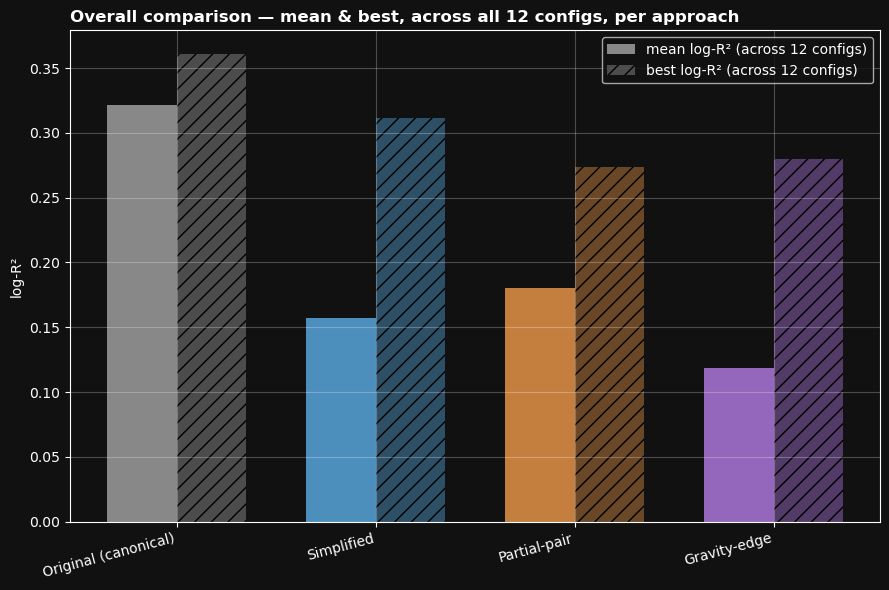

In [10]:
if variant_rows:
    overall_rows = []
    orig_series = pd.Series(orig_vals, index=configs)
    overall_rows.append({
        'approach': 'Original (canonical)',
        'mean_log_r2': orig_series.mean(), 'best_log_r2': orig_series.max(),
        'mean_delta_vs_original': 0.0, 'n_held_of_12': len(orig_series), 'n_improved_of_12': 0,
    })
    for label in variant_labels:
        sub = all_variants[all_variants.variant == label]
        overall_rows.append({
            'approach': label.splitlines()[0],
            'mean_log_r2': sub['log_r2'].mean(), 'best_log_r2': sub['log_r2'].max(),
            'mean_delta_vs_original': sub['delta_vs_original'].mean(),
            'n_held_of_12': int((sub['delta_vs_original'] >= -0.01).sum()),
            'n_improved_of_12': int((sub['delta_vs_original'] > 0.01).sum()),
        })
    overall_df = pd.DataFrame(overall_rows).set_index('approach')

    fig, ax = plt.subplots(figsize=(9, 6))
    colors_overall = [GRAY, BLUE, ORANGE, PURPLE][:len(overall_df)]
    x = np.arange(len(overall_df)); w = 0.35
    ax.bar(x - w/2, overall_df['mean_log_r2'], w, label='mean log-R² (across 12 configs)', color=colors_overall)
    ax.bar(x + w/2, overall_df['best_log_r2'], w, label='best log-R² (across 12 configs)',
           color=colors_overall, alpha=0.5, hatch='//')
    ax.set_xticks(x); ax.set_xticklabels(overall_df.index, rotation=15, ha='right')
    ax.set_ylabel('log-R²')
    ax.set_title('Overall comparison — mean & best, across all 12 configs, per approach', loc='left', fontweight='bold')
    ax.legend()
    fig.tight_layout()

    print('=== Overall summary, one row per approach ===')
    print(overall_df.round(4).to_string())

    best_approach = overall_df['mean_log_r2'].idxmax()
    print(f"\nBest approach overall (by mean log-R²): {best_approach}")
    print(f"({overall_df.loc[best_approach, 'n_held_of_12']}/12 configs held steady vs. original, "
          f"{overall_df.loc[best_approach, 'n_improved_of_12']}/12 genuinely improved)")
else:
    print('No retraining-removal variants available yet -- nothing to summarize.')